In [1]:
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

In [2]:
Ticker = ['^NSEI']

# Indicate the start and end dates
start = dt.datetime.now().replace(year=dt.datetime.now().year - 1)
end = dt.datetime.now()

nifty = yfin.download(Ticker, start = start, end = end)
print(nifty)

[*********************100%***********************]  1 of 1 completed

Price              Close          High           Low          Open   Volume
Ticker             ^NSEI         ^NSEI         ^NSEI         ^NSEI    ^NSEI
Date                                                                       
2025-06-02  24716.599609  24754.400391  24526.150391  24669.699219   311100
2025-06-03  24542.500000  24845.099609  24502.150391  24786.300781   349300
2025-06-04  24620.199219  24644.250000  24530.449219  24560.449219   280900
2025-06-05  24750.900391  24899.849609  24613.099609  24691.199219   388400
2025-06-06  25003.050781  25029.500000  24671.449219  24748.699219   335600
...                  ...           ...           ...           ...      ...
2026-05-25  24031.699219  24054.449219  23922.849609  23940.250000   351200
2026-05-26  23913.699219  24089.800781  23885.449219  24004.099609   387900
2026-05-27  23907.150391  23983.199219  23858.250000  23880.349609   531600
2026-05-29  23547.750000  24002.800781  23484.750000  23902.150391  1198000
2026-06-01  

In [3]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2025-06-02,24716.599609,24754.400391,24526.150391,24669.699219,311100
2025-06-03,24542.500000,24845.099609,24502.150391,24786.300781,349300
2025-06-04,24620.199219,24644.250000,24530.449219,24560.449219,280900
2025-06-05,24750.900391,24899.849609,24613.099609,24691.199219,388400
2025-06-06,25003.050781,25029.500000,24671.449219,24748.699219,335600


In [4]:
nifty['Close'].pct_change(1) * 100

Ticker,^NSEI
Date,
2025-06-02,NaN
2025-06-03,-0.704383
2025-06-04,0.316590
2025-06-05,0.530870
2025-06-06,1.018752
...,...
2026-05-25,1.317064
2026-05-26,-0.491018
2026-05-27,-0.027385


In [5]:
nifty['Daily returns'] = nifty['Close'].pct_change(1) * 100
nifty['Daily returns']

Date
2025-06-02         NaN
2025-06-03   -0.704383
2025-06-04    0.316590
2025-06-05    0.530870
2025-06-06    1.018752
                ...   
2026-05-25    1.317064
2026-05-26   -0.491018
2026-05-27   -0.027385
2026-05-29   -1.503318
2026-06-01   -0.630418
Name: Daily returns, Length: 246, dtype: float64

In [6]:
nifty['Daily_Returns'] = nifty['Daily returns'].fillna(0)
nifty.Daily_Returns

Date
2025-06-02    0.000000
2025-06-03   -0.704383
2025-06-04    0.316590
2025-06-05    0.530870
2025-06-06    1.018752
                ...   
2026-05-25    1.317064
2026-05-26   -0.491018
2026-05-27   -0.027385
2026-05-29   -1.503318
2026-06-01   -0.630418
Name: Daily_Returns, Length: 246, dtype: float64

In [7]:
nifty.Daily_Returns.mean()

-0.018979551674651523

In [8]:
nifty.Daily_Returns.std()

0.8115405228010769

In [9]:
#log_returns = ln(p(t) / p(t -1)) = ln(p(t)) - ln(p(t - 1))

In [10]:
nifty['log_return'] = np.log(nifty['Close']).diff()

In [11]:
nifty['log_return']

Date
2025-06-02         NaN
2025-06-03   -0.007069
2025-06-04    0.003161
2025-06-05    0.005295
2025-06-06    0.010136
                ...   
2026-05-25    0.013085
2026-05-26   -0.004922
2026-05-27   -0.000274
2026-05-29   -0.015147
2026-06-01   -0.006324
Name: log_return, Length: 246, dtype: float64

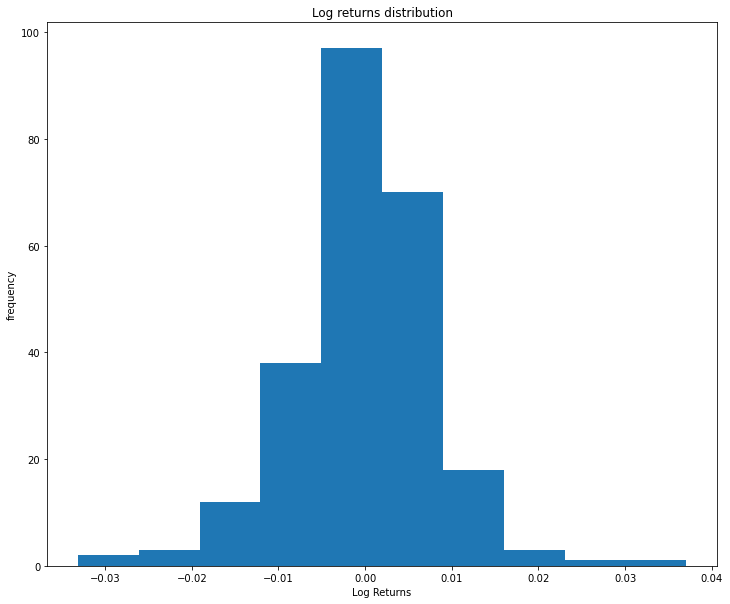

In [12]:
log_return = nifty['log_return']

plt.figure(figsize = (12, 10))
plt.hist(log_return)
plt.title('Log returns distribution')
plt.xlabel('Log Returns')
plt.ylabel('frequency')


plt.show()

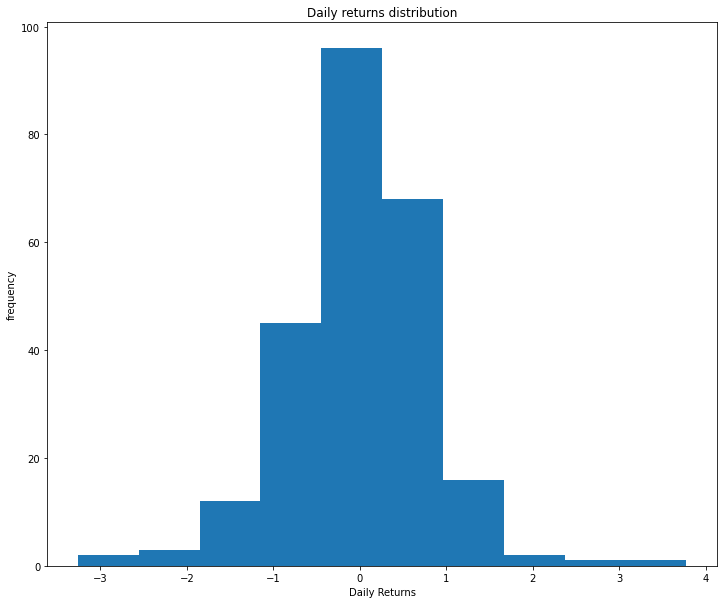

In [13]:
returns = nifty['Daily_Returns'].to_frame()

plt.figure(figsize = (12, 10))
plt.hist(returns)
plt.title('Daily returns distribution')
plt.xlabel('Daily Returns')
plt.ylabel('frequency')

plt.show()

In [14]:
stats.describe(nifty['Daily_Returns'])

DescribeResult(nobs=246, minmax=(-3.2620779262169552, 3.7783792956159967), mean=-0.018979551674651533, variance=0.6585980201482459, skewness=-0.05472633490828919, kurtosis=2.772489439319272)

In [15]:
stats.describe(nifty['log_return'])

DescribeResult(nobs=246, minmax=(nan, nan), mean=nan, variance=nan, skewness=nan, kurtosis=nan)

In [16]:
#build a cdf for returns, from scratch
returns

,Daily_Returns
Date,
2025-06-02,0.000000
2025-06-03,-0.704383
2025-06-04,0.316590
2025-06-05,0.530870
2025-06-06,1.018752
...,...
2026-05-25,1.317064
2026-05-26,-0.491018
2026-05-27,-0.027385


In [17]:
returns_cdf = returns.sort_values(by = 'Daily_Returns', ascending = True, inplace = False)
returns_cdf['rowNumber'] = range(1, len(returns_cdf) + 1)
returns_cdf['cdf'] = returns_cdf.rowNumber / len(returns_cdf)

In [18]:
returns_cdf

,Daily_Returns,rowNumber,cdf
Date,,,
2026-03-19,-3.262078,1,0.004065
2026-03-23,-2.603775,2,0.008130
2026-03-30,-2.139386,3,0.012195
2026-03-27,-2.088905,4,0.016260
2026-03-13,-2.064587,5,0.020325
...,...,...,...
2026-04-15,1.630064,242,0.983740
2026-03-25,1.719806,243,0.987805
2026-03-24,1.775668,244,0.991870


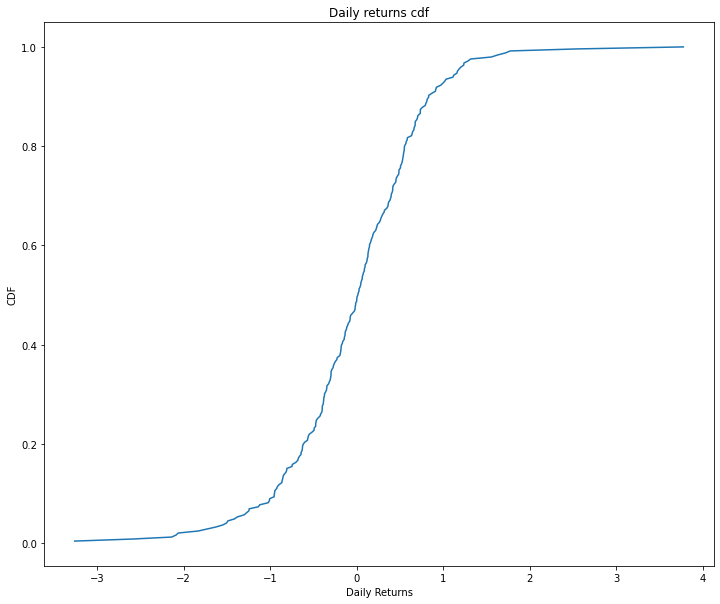

In [19]:
plt.figure(figsize = (12, 10))
plt.plot(returns_cdf.Daily_Returns, returns_cdf.cdf)
plt.title('Daily returns cdf')
plt.xlabel('Daily Returns')
plt.ylabel('CDF')

plt.show()

In [20]:
returns

,Daily_Returns
Date,
2025-06-02,0.000000
2025-06-03,-0.704383
2025-06-04,0.316590
2025-06-05,0.530870
2025-06-06,1.018752
...,...
2026-05-25,1.317064
2026-05-26,-0.491018
2026-05-27,-0.027385


In [21]:
returns_sorted = returns.sort_values('Daily_Returns')
returns_sorted['cdf'] = stats.norm.cdf(returns_sorted.Daily_Returns)

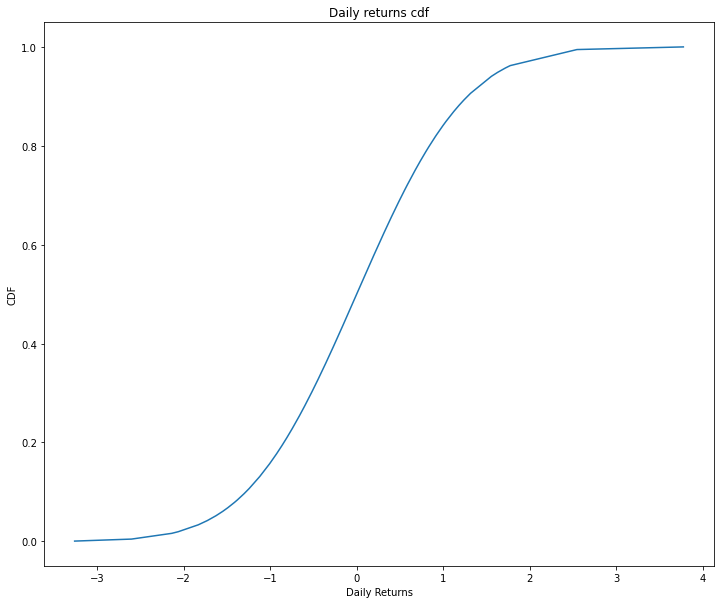

In [22]:
plt.figure(figsize = (12, 10))
plt.plot(returns_sorted.Daily_Returns, returns_sorted.cdf)
plt.title('Daily returns cdf')
plt.xlabel('Daily Returns')
plt.ylabel('CDF')

plt.show()

In [23]:
returns = nifty.Daily_Returns

In [24]:
stats.norm.fit(returns)

(-0.018979551674651533, 0.8098893704846767)